# SpaCy Span Categorization Model Training

This notebook demonstrates the end-to-end process of training a SpaCy span categorization (spancat) model for entity extraction. The process includes:

1. Data preparation
2. Model training
3. Model evaluation
4. Inference on new documents

## Setup and Requirements

Required packages:
- spacy
- pandas
- numpy
- scikit-learn (for evaluation metrics)

In [4]:
!pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://dl.cloudsmith.io/yWsguJ7XarcEgD4C/ffma/python/python/simple/


In [2]:
import pickle
import spacy
import pandas as pd
import numpy as np
from pathlib import Path
from spacy.tokens import DocBin
import os
# from sklearn.metrics import classification_report
import json
import random
from glob import glob

## 1. Data Preparation

We'll create functions to load and prepare our training data. The input will be:
- Raw text files
- Entity annotations in the format: {text: str, entities: List[{start: int, end: int, label: str}]}

In [3]:
# functions to read raw docs and entities with
def read_raw_docs(root_folder, extensions=['.txt']):
    """
    Reads files recursively from a root folder.
    
    :param root_folder: The root folder to start searching.
    :param extensions: Optional list of file extensions to filter (e.g., ['.txt', '.md']).
    """
    corpus = ''
    for dirpath, _, filenames in os.walk(root_folder):
        print(dirpath)
        for filename in filenames:
            print(filename)
            if extensions is None or any(filename.endswith(ext) for ext in extensions):
                file_path = os.path.join(dirpath, filename)
                try:
                    with open(file_path, 'r', encoding='utf-8') as file:
                        print(f"Reading {file_path}")
                        corpus += file.read()
                except Exception as e:
                    print(f"Error reading {file_path}: {e}")
    return corpus

def read_json_docs(root_folder, extensions=[".json"]):
    """
    Reads JSON files recursively from a root folder and merges their contents into a single dictionary,
    extending list values for shared keys.
    
    :param root_folder: The root folder to start searching.
    :param extensions: Optional list of file extensions to filter (default: ['.json']).
    :return: A dictionary containing the merged content of all JSON files.
    """
    if extensions is None:
        raise ValueError(f"no file extension provided. Can't read.")

    merged_dict = {}
    for dirpath, _, filenames in os.walk(root_folder):
        print(dirpath)
        for filename in filenames:
            if any(filename.endswith(ext) for ext in extensions):
                file_path = os.path.join(dirpath, filename)
                try:
                    with open(file_path, 'r', encoding='utf-8') as file:
                        if "_cleaned.json" in file_path:
                            print(f"Reading {file_path}")
                            file_content = json.load(file)
                            if not isinstance(file_content, dict) or not all(isinstance(v, list) for v in file_content.values()):
                                raise ValueError(f"Expected a dictionary with list values in {file_path}.")
                            for key, new_value in file_content.items():
                                if key in merged_dict:
                                    print(f"extending {key} with {new_value}")
                                    merged_dict[key].extend(new_value)  # Extend the list
                                    print(f"merged_dict[key] new: {merged_dict[key]}")
                                    pass
                                else:
                                    print(f"initialising: {key}")
                                    merged_dict[key] = new_value  # Add new key-value pair if it doesn't exist
                except Exception as e:
                    print(f"Error reading {file_path}: {e}")
    return merged_dict

In [41]:
RAW_TEXT_DIR = str(Path('../../data/processed/pre_processing/ocr_output/').resolve())
ENTITIES_DIR = str(Path('../../data/processed/pre_processing/llm_entities/').resolve())
SPAN_KEY='sc'

In [27]:
docs = read_raw_docs(RAW_TEXT_DIR)
entities = read_json_docs(ENTITIES_DIR)

C:\Users\ramnic\ff-entity-tagging-poc\data\processed\pre_processing\ocr_output
01 - MRC - Action Item register 2024 (A1224500).txt
Reading C:\Users\ramnic\ff-entity-tagging-poc\data\processed\pre_processing\ocr_output\01 - MRC - Action Item register 2024 (A1224500).txt
01 ARC - Decision item register 2024 (A1136154).txt
Reading C:\Users\ramnic\ff-entity-tagging-poc\data\processed\pre_processing\ocr_output\01 ARC - Decision item register 2024 (A1136154).txt
01 IC - Action item register 2024 (A1108669).txt
Reading C:\Users\ramnic\ff-entity-tagging-poc\data\processed\pre_processing\ocr_output\01 IC - Action item register 2024 (A1108669).txt
01 IC - Annual calendar 2024 (A1081726).txt
Reading C:\Users\ramnic\ff-entity-tagging-poc\data\processed\pre_processing\ocr_output\01 IC - Annual calendar 2024 (A1081726).txt
ARC & MRC - 20241122 - Minutes (A604869) (A1230142).txt
Reading C:\Users\ramnic\ff-entity-tagging-poc\data\processed\pre_processing\ocr_output\ARC & MRC - 20241122 - Minutes (A604

In [28]:
print(docs[:500])

Action Items from Previous Meetings

Date



Action

Status Update/Due date

Owner



 





 NOTE: The MRC Action Item Register was created in November 2024 and does not capture actions from previous meetings










Completed action items

Date

Completed

Action

Owner






































































		A1108669	Confidential 	2

	A1108669                                                                       Confidential		                                 


In [29]:
# lets clean up \n characters
docs = docs.replace("\n", " ")

In [30]:
# print number of characters in corpus - spacy has to work with <1mil characters
print(f"number of characters in our corpus: {len(docs)}")

number of characters in our corpus: 7342995


In [31]:
# establish a dictionary of entity categories - for training spaCy custom NER later (per doc)
ent_patterns_list = [] # global scope
for ent_category, ent_list in entities.items():
    for ent in ent_list:
        # gets rid of empty entities
        if ent != '':
            ent_patterns_list.append(
                # {"label": ent_category, "pattern": [{"lower": ent}]}
                {"label": ent_category, "pattern": ent}
            )
print(ent_patterns_list[:10])

[{'label': 'fund_managers', 'pattern': 'OMERS'}, {'label': 'fund_managers', 'pattern': 'Greystar Australia Pty Ltd'}, {'label': 'fund_managers', 'pattern': 'QRT'}, {'label': 'fund_managers', 'pattern': 'Oakley Capital'}, {'label': 'fund_managers', 'pattern': 'DWS Strategic Alpha'}, {'label': 'fund_managers', 'pattern': 'SquarePoint'}, {'label': 'fund_managers', 'pattern': 'Hg'}, {'label': 'fund_managers', 'pattern': 'HG Capital'}, {'label': 'fund_managers', 'pattern': 'KKR Asset Based Finance Partners II'}, {'label': 'investments', 'pattern': 'Cash'}]


In [32]:
# spacy can only work with chunks <1mil characters at a time. chunk the corpus below
def divide_string_into_n_chunks(input_string, num_chunks):
    """
    Divides a string into `num_chunks` chunks and stores them in a dictionary.

    :param input_string: The string to be divided.
    :param num_chunks: The number of chunks.
    :return: A dictionary where the keys are indices, and the values are string chunks.
    """
    # Calculate the chunk size (integer division)
    chunk_size = len(input_string) // num_chunks
    remainder = len(input_string) % num_chunks
    
    # Dictionary to store chunks
    chunks_dict = {}
    start_index = 0

    for i in range(num_chunks):
        # Calculate the end index for the current chunk
        end_index = start_index + chunk_size + (1 if i < remainder else 0)  # Distribute remainder evenly
        chunks_dict[i] = input_string[start_index:end_index]
        start_index = end_index  # Update start index for next chunk
    
    return chunks_dict

# Example usage:
num_chunks = 8
doc_chunk_dict = divide_string_into_n_chunks(docs, num_chunks)

In [33]:
from spacy.training import Example

In [34]:
# create overall train-test dataset considering the chunks
TRAIN_TEST_DATASET = []
for _, chunk in doc_chunk_dict.items():
    nlp = spacy.load("en_core_web_sm") #m, lg, xl, tf
    nlp.add_pipe("sentencizer")

    # first chunk up the docs
    doc = nlp(chunk)

    corpus = []

    # into sentences
    for sent in doc.sents:
        corpus.append(sent.text)

    # re-initialise NLP pipeline to just have the entity ruler
    nlp = spacy.blank("en")
    ruler = nlp.add_pipe("entity_ruler")
    ruler.add_patterns(ent_patterns_list)

    # then chunk up the sentences
    for sentence in corpus:
        doc = nlp(sentence)
        train_test_entities = []

        # into entities
        for ent in doc.ents:
            train_test_entities.append([ent.start_char, ent.end_char, ent.label_]) 
        if len(train_test_entities) > 0: # post process to remove any items where entities list is empty
            TRAIN_TEST_DATASET.append([sentence, {"spans": {"sc": train_test_entities}}])
print(TRAIN_TEST_DATASET[:2])

[['IC members  22/02/2021  PE to provide estimate of the quantum of revaluation they are expecting with December 20 valuations to Overlays.  ', {'spans': {'sc': [[127, 135, 'investments']]}}], ['WN  9/02/2021  Overlays/Equities to provide reporting on the funds the geographic equity exposure, including the total exposure to each region.  ', {'spans': {'sc': [[15, 23, 'investments']]}}]]


In [35]:
def create_docbin(data, nlp, span_key="sc"):
    """
    Converts a list of (text, annotation) pairs into a spaCy DocBin.

    Parameters:
    - data: List of tuples, where each tuple is (text, annotation). 
      The annotation should be a dict with a "spans" key, e.g.,
      {"spans": {"sc": [(start, end, label), ...]}}.
    - nlp: A spaCy Language object.
    - span_key: The key under which span annotations are stored (default "sc").

    Returns:
    - A DocBin object containing all the processed Doc objects.
    """
    doc_bin = DocBin()
    for text, ann in data:
        doc = nlp.make_doc(text)
        spans = []
        for start_char, end_char, label in ann["spans"][span_key]:
            span = doc.char_span(start_char, end_char, label=label)
            if span is not None:
                spans.append(span)
            else:
                # Optionally handle misaligned spans here.
                print(f"Warning: Could not create span for text '{text[start_char:end_char]}'")
        doc.spans[span_key] = spans
        doc_bin.add(doc)
    return doc_bin

In [36]:
def create_spancat_training_eval_data(
    data,
    nlp,
    span_key="sc",
    train_ratio=0.8,
    train_output_path="train_spancat.spacy",
    eval_output_path="eval_spancat.spacy"
):
    """
    Shuffles and splits the dataset into training and evaluation sets, converts them to DocBins,
    and saves the resulting files.

    Parameters:
    - data: List of (text, annotation) pairs.
    - nlp: A spaCy Language object.
    - span_key: Key for the span annotations (default "sc").
    - train_ratio: Fraction of data to use for training (default 0.8).
    - train_output_path: File path to save the training DocBin.
    - eval_output_path: File path to save the evaluation DocBin.
    """
    # Shuffle the data randomly
    random.shuffle(data)
    
    # Split the data into training and evaluation sets
    split_index = int(len(data) * train_ratio)
    train_data = data[:split_index]
    eval_data = data[split_index:]
    
    # Convert each set into a DocBin
    train_doc_bin = create_docbin(train_data, nlp, span_key)
    eval_doc_bin = create_docbin(eval_data, nlp, span_key)
    
    # Save the DocBins to disk
    train_doc_bin.to_disk(train_output_path)
    eval_doc_bin.to_disk(eval_output_path)
    
    print(f"Saved {len(train_data)} training examples to {train_output_path}")
    print(f"Saved {len(eval_data)} evaluation examples to {eval_output_path}")

    return train_data, eval_data

In [37]:
nlp = spacy.blank("en")
TRAIN_DATA, TEST_DATA = create_spancat_training_eval_data(TRAIN_TEST_DATASET, nlp)

Saved 2176 training examples to train_spancat.spacy
Saved 544 evaluation examples to eval_spancat.spacy


In [38]:
with open('train_entity_annots.pkl', 'wb') as train_file:
    pickle.dump(TRAIN_DATA, train_file)

with open('test_entity_annots.pkl', 'wb') as test_file:
    pickle.dump(TEST_DATA, test_file)

## Data Analysis

In [39]:
TRAIN_TEST_DATASET[:2]

[['| AUD                      |                                  |                                   | | Class NEA Omnibus Co-investment  Vehicle                                                            | Private Equity                                                                                                        | Started                                  |                      ',
  {'spans': {'sc': [[204, 218, 'investments']]}}],
 ['Bridgewater changing tax status (increased US equities trading)                         | Alternatives            | Started      |                    | AUD                     | 14/02/2025              |                       ',
  {'spans': {'sc': [[90, 102, 'investments']]}}]]

In [42]:
# entity categories in train and test data
def count_entity_categories(data):
    results_aggregate, results_granular = {}, {}
    funds, fund_managers = set(), set()
    for sent, annotations in data:
        # print(annotations)
        for annot in annotations['spans'][SPAN_KEY]:
            ent = sent[annot[0]:annot[1]]
            ent_category = annot[2]
            if ent_category not in results_aggregate:
                results_aggregate[ent_category] = 1
            else:
                # print(f"ent category: {ent_category} has count: {result_dict[ent_category]}")
                results_aggregate[ent_category] += 1
            if ent_category == 'investments':
                funds.add(ent)
            elif ent_category == 'fund_managers':
                fund_managers.add(ent)
    results_granular["investments"] = funds
    results_granular["fund_managers"] = fund_managers
    
    return results_aggregate, results_granular

train_ds_agg, train_ds_granular = count_entity_categories(TRAIN_DATA)
test_ds_agg, test_ds_granular = count_entity_categories(TEST_DATA)

In [43]:
# duplicates considered
print(f"Training dataset (number of entities - duplicates incl):")
print(train_ds_agg)
print(f"Testing dataset (number of entities - duplicates incl):")
print(test_ds_agg)

Training dataset (number of entities - duplicates incl):
{'investments': 2335, 'fund_managers': 593}
Testing dataset (number of entities - duplicates incl):
{'investments': 600, 'fund_managers': 133}


In [44]:
# unique ents considered
print(f"Training dataset (number of entities unique):")
print(f"funds: {len(train_ds_granular["investments"])}, fund managers: {len(set(train_ds_granular["fund_managers"]))}")
print(f"Testing dataset (number of entities unique):")
print(f"funds: {len(set(test_ds_granular["investments"]))}, fund managers: {len(set(test_ds_granular["fund_managers"]))}")

Training dataset (number of entities unique):
funds: 33, fund managers: 8
Testing dataset (number of entities unique):
funds: 26, fund managers: 6


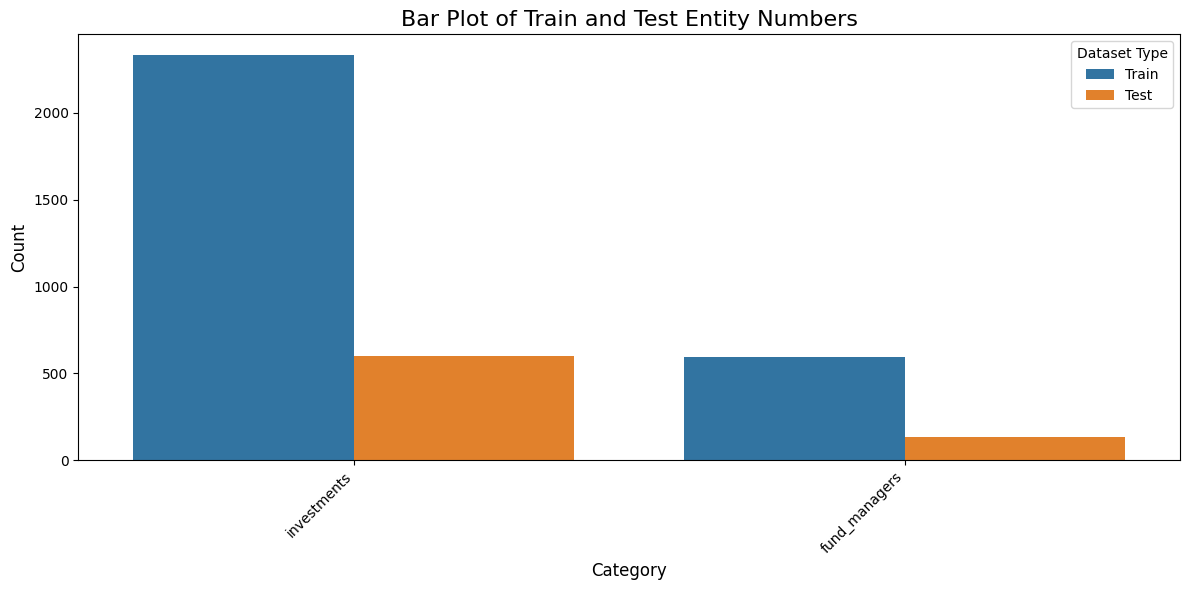

In [45]:
# plot our numer of train-test entities to get an idea of what entity categories the model will learn really well

import seaborn as sns 
import matplotlib.pyplot as plt

# Convert dictionaries into a DataFrame for plotting
train_df = pd.DataFrame({'Category': train_ds_agg.keys(), 'Count': train_ds_agg.values(), 'Type': 'Train'})
test_df = pd.DataFrame({'Category': test_ds_agg.keys(), 'Count': test_ds_agg.values(), 'Type': 'Test'})

# Combine the dataframes
combined_df = pd.concat([train_df, test_df])

# Create a bar plot
plt.figure(figsize=(12, 6))
sns.barplot(data=combined_df, x='Category', y='Count', hue='Type')

# Enhance the plot
plt.title('Bar Plot of Train and Test Entity Numbers', fontsize=16)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.legend(title='Dataset Type', fontsize=10)
plt.tight_layout()

# Show the plot
plt.show()

## 2. Model Configuration and Training

We'll set up a basic spancat pipeline and train it on our data.

In [97]:
# this CLI command creates a config file for training a spancat model
# run in terminal if jupyter doesn't work
!python -m spacy init config config.cfg --lang en --pipeline spancat

C:\ProgramData\anaconda3\python.exe: No module named spacy


In [98]:
# this CLI command feeds in the binarised training and testing files to train and eval the spacy model with
# --output specifies where to output the best performing model and associated artefacts
# try the below in a terminal if it can't run in jupyter notebook
!python -m spacy train config.cfg --output ./output --paths.train ./train_spancat.spacy --paths.dev ./eval_spancat.spacy

C:\ProgramData\anaconda3\python.exe: No module named spacy


## 3. Model Evaluation

We'll create functions to evaluate the model's performance.

In [46]:
def evaluate_spancat_model(nlp, eval_doc_bin_path, span_key="sc"):
    """
    Evaluate a trained spancat model on evaluation data.
    
    Parameters:
    - nlp: A spaCy Language object loaded with the trained spancat model.
    - eval_doc_bin_path: Path to the evaluation .spacy file (DocBin).
    - span_key: The key under which spans are stored (default "sc").
    
    Returns:
    - A dictionary containing evaluation scores.
    """
    # Load evaluation DocBin
    eval_doc_bin = DocBin().from_disk(eval_doc_bin_path)
    examples = []
    for gold_doc in eval_doc_bin.get_docs(nlp.vocab):
        # Get a prediction from the model
        pred_doc = nlp(gold_doc.text)
        # Create an Example comparing the prediction with the gold-standard annotation
        example = Example(pred_doc, gold_doc)
        examples.append(example)
    
    # Use spaCy's built-in evaluation (which computes metrics for components in the pipeline)
    scores = nlp.evaluate(examples)
    return scores

In [47]:
trained_model = spacy.load("output/model-best")

# eval scores
scores = evaluate_spancat_model(nlp=trained_model, eval_doc_bin_path='eval_spancat.spacy')
scores

{'token_acc': 1.0,
 'token_p': 1.0,
 'token_r': 1.0,
 'token_f': 1.0,
 'spans_sc_p': 0.9760900140646976,
 'spans_sc_r': 0.946793997271487,
 'spans_sc_f': 0.961218836565097,
 'spans_sc_per_type': {'investments': {'p': 0.9878260869565217,
   'r': 0.9466666666666667,
   'f': 0.9668085106382979},
  'fund_managers': {'p': 0.9264705882352942,
   'r': 0.9473684210526315,
   'f': 0.9368029739776952}},
 'speed': 5356.161677358268}

Let's plot the `evaluation` metrics for better visualisation below:

In [ ]:
0.9760900140646976/

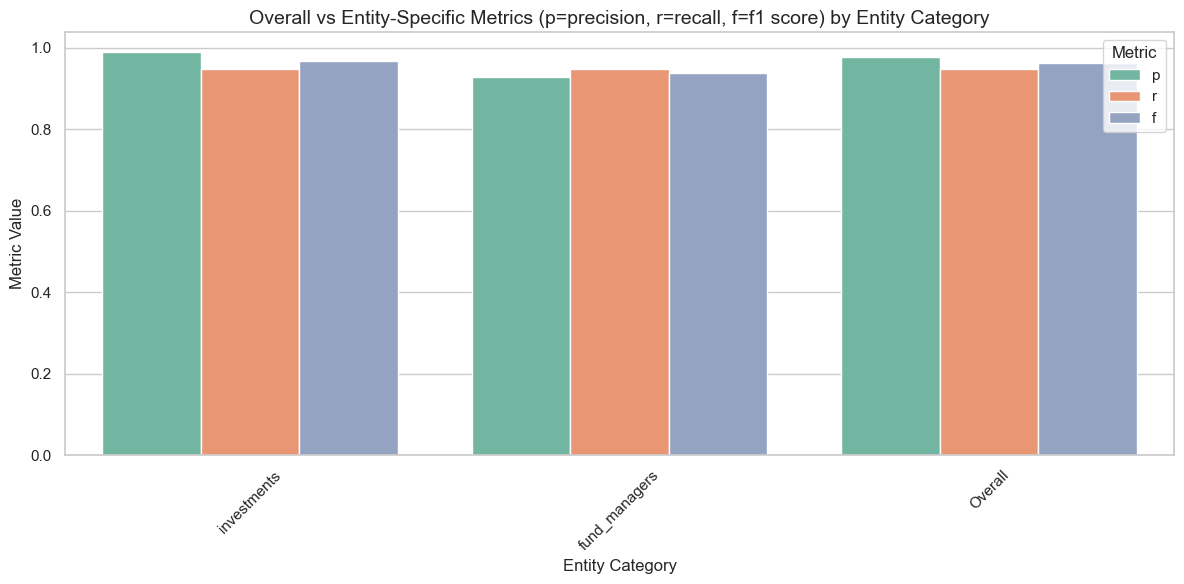

In [49]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

data = scores

# Extract the overall metrics
overall_metrics = {
    'p': data['spans_sc_p'],
    'r': data['spans_sc_r'],
    'f': data['spans_sc_f']
}

# Extract the entity-specific metrics
entity_metrics = data['spans_sc_per_type']

# Convert the data to a DataFrame for easier plotting
entity_categories = list(entity_metrics.keys())
entity_p = [entity_metrics[ent]['p'] for ent in entity_categories]
entity_r = [entity_metrics[ent]['r'] for ent in entity_categories]
entity_f = [entity_metrics[ent]['f'] for ent in entity_categories]

# Create a DataFrame for entity-specific metrics in long format
df_entity = pd.DataFrame({
    'Entity Category': entity_categories * 3,  # Repeating the entity categories for each metric (p, r, f)
    'Metric': ['p'] * len(entity_categories) + ['r'] * len(entity_categories) + ['f'] * len(entity_categories),
    'Value': entity_p + entity_r + entity_f
})

# Create a DataFrame for overall metrics (one row for each metric)
df_overall = pd.DataFrame({
    'Entity Category': ['Overall'] * 3,
    'Metric': ['p', 'r', 'f'],
    'Value': [overall_metrics['p'], overall_metrics['r'], overall_metrics['f']]
})

# Concatenate the entity-specific and overall metrics
df_combined = pd.concat([df_entity, df_overall], ignore_index=True)

# Set up the plot
plt.figure(figsize=(12, 6))
sns.set(style="whitegrid")

# Plot the bars
sns.barplot(x="Entity Category", y="Value", hue="Metric", data=df_combined, palette="Set2")

# Customize the plot
plt.title("Overall vs Entity-Specific Metrics (p=precision, r=recall, f=f1 score) by Entity Category", fontsize=14)
plt.xlabel("Entity Category", fontsize=12)
plt.ylabel("Metric Value", fontsize=12)
plt.xticks(rotation=45)
plt.legend(title="Metric", loc="upper right")

# Show the plot
plt.tight_layout()
plt.show()

In [22]:
# train scores.

train_scores = evaluate_spancat_model(nlp=trained_model, eval_doc_bin_path='train_spancat.spacy')
train_scores

{'token_acc': None,
 'token_p': None,
 'token_r': None,
 'token_f': None,
 'spans_sc_p': None,
 'spans_sc_r': None,
 'spans_sc_f': None,
 'spans_sc_per_type': None,
 'speed': 0.0}

## 4. Inference

Finally, we'll create a function to use the trained model for inference on new documents.

In [128]:
def predict_entities(nlp, text):
    """Use the trained model to predict entities in new text."""
    doc = nlp(text)
    predictions = []

    spans =  doc.spans["sc"]
    for span, confidence in zip(spans, spans.attrs["scores"]):
        predictions.append({
            'sentence': doc,
            'text': span.text,
            'label': span.label_,
            'confidence': confidence
        })
    
    return predictions

In [129]:
with open('test_entity_annots.pkl', 'rb') as test_file:
    TEST_DATA = pickle.load(test_file)
TEST_DATA[:1]

[["This becomes the starting point for future opex forecasts - · Up or downwards adjustments are made to the base year opex to account for changes in costs that are not captured by the base year or the trend - · The trend component accounts for changes in opex over time due to factors like input price growth, output growth, and productivity improvements - · If Transgrid manages to operate more efficiently than the AER's opex allowance, it can achieve opex outperformance.",
  {'spans': {'sc': [[360, 369, 'investments']]}}]]

In [138]:
test_predictions = []
for sent, _ in TEST_DATA:
    test_predictions.extend(predict_entities(trained_model, sent))

In [139]:
test_predictions[:1]

[{'sentence': This becomes the starting point for future opex forecasts - · Up or downwards adjustments are made to the base year opex to account for changes in costs that are not captured by the base year or the trend - · The trend component accounts for changes in opex over time due to factors like input price growth, output growth, and productivity improvements - · If Transgrid manages to operate more efficiently than the AER's opex allowance, it can achieve opex outperformance.,
  'text': 'Transgrid',
  'label': 'investments',
  'confidence': np.float32(0.9998215)}]

In [145]:
min_confidence, max_confidence, ave_confidence = 1, 0, 0
confidence_scores = []
for pred_item in test_predictions:
    confidence = pred_item['confidence']
    confidence_scores.append(confidence)
    if confidence < min_confidence:
        min_confidence = confidence
    elif confidence > max_confidence:
        max_confidence = max_confidence
    ave_confidence += confidence
ave_confidence = ave_confidence / len(test_predictions)
print(f"""
On evaluation set: 
average confidence score: {ave_confidence}
minimum confidence score: {min_confidence}
maximum confidence score: {max_confidence}
""")


On evaluation set: 
average confidence score: 0.9870715737342834
minimum confidence score: 0.5765022039413452
maximum confidence score: 0



(array([  1.,   7.,   2.,   0.,   1.,   3.,   6.,   8.,  16., 663.]),
 array([0.5765022 , 0.618846  , 0.66118973, 0.70353353, 0.74587727,
        0.78822106, 0.83056486, 0.87290859, 0.91525239, 0.95759618,
        0.99993992]),
 <BarContainer object of 10 artists>)

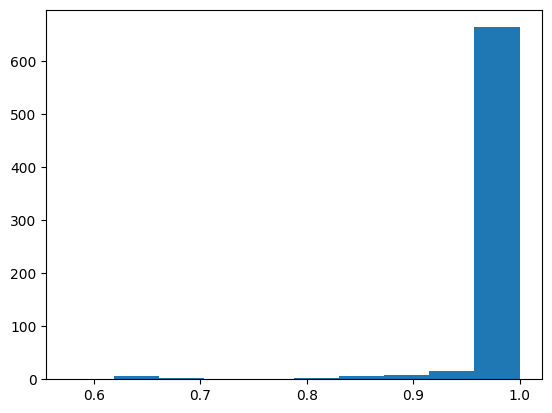

In [146]:
plt.hist(confidence_scores)

In [148]:
# test entities total # captured in predictions
pred_funds, pred_fund_mgrs = set(), set()
for pred_item in test_predictions:
    predicted_entity = pred_item['text']
    if pred_item['label'] == 'investments':
        pred_funds.add(predicted_entity)
    if pred_item['label'] == 'fund_managers':
        pred_fund_mgrs.add(predicted_entity)